In [1]:
#載入numpy函式庫(套件)
import numpy as np 
#載入cifar10類別
from tensorflow.keras.datasets import cifar10 
#載入keras 的序列式模型類別
from tensorflow.keras.models import Sequential 
#載入Dense, Flatten, Conv2D, MaxPooling2D, Dropout等類別
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout 
#載入to_categorical函式
from tensorflow.keras.utils import to_categorical 


In [2]:
#3-0 認識Cifar10彩色圖片資料集
#指定亂數種子
seed = 5811          #亂數種子, 可以改用其他數字
np.random.seed(seed) #啟動亂數種子
#載入 Cifar10 資料集, 如果是第一次載入會自行下載資料集
(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()

In [3]:
#顯示訓練和測試資料集的形狀
print("X_train.shape: ", X_train.shape)  #訓練資料集的輸入形狀
print("Y_train.shape: ", Y_train.shape)  #訓練資料集的標籤資料
print("X_test.shape: ", X_test.shape)    #測試資料集的輸入形狀
print("Y_test.shape: ", Y_test.shape)    #測試資料集的標籤資料

X_train.shape:  (50000, 32, 32, 3)
Y_train.shape:  (50000, 1)
X_test.shape:  (10000, 32, 32, 3)
Y_test.shape:  (10000, 1)


In [4]:
#顯示訓練資料集中的第1張圖片資料
print(X_train[0])   # 像素值資料
print(Y_train[0])   # 標籤資料

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
[6]


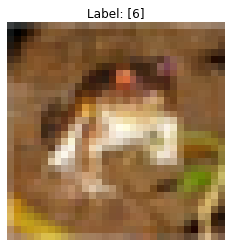

In [5]:
#使用Matplotlib顯示青蛙的彩色圖片
import matplotlib.pyplot as plt        #滙入matplotlib.pyplot函數
plt.imshow(X_train[0], cmap="binary")  #顯示X_train[0],  colormap使用binary
plt.title("Label: " + str(Y_train[0])) #設定圖表標題
plt.axis("off") #不顯示座標
plt.show()      #顯示圖片

In [6]:
#因為是固定範圍, 所以執行正規化, 從 0-255 至 0-1
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

In [7]:
#One-hot編碼
Y_train = to_categorical(Y_train)
Y_test = to_categorical(Y_test)

In [8]:
#3.2 步驟二：定義模型
#建立一個序列模型
model = Sequential()                                          
#Conv2D(卷積層), 有32個大小為3*3的filter(過濾器)，保留原圖片大小, 輸入的資料為(32*32*3)，啟動函數為relu
model.add(Conv2D(32, kernel_size=(3, 3), padding="same",      
                 input_shape=(32,32,3), activation="relu"))  
#MaxPooling2D(池化層)
model.add(MaxPooling2D(pool_size=(2, 2)))                     
#Dropout(丟棄層) 隨機放棄25%的神經元
model.add(Dropout(0.25))                                      
#Conv2D(卷積層), 64個大小為3*3的filter(過濾器)，保留原圖片大小, 輸入的資料為(32*32*3)，啟動函數為relu
model.add(Conv2D(64, kernel_size=(3, 3),                     
                   padding="same", activation="relu"))        
#MaxPooling2D(池化層)
model.add(MaxPooling2D(pool_size=(2, 2)))
#Dropout(丟棄層) 隨機放棄25%的神經元                     
model.add(Dropout(0.25))                                      
#Flattening(展平層) 將高維陣列轉為1維
model.add(Flatten())                                          
#Dense(密集層)，有512個神經元，啟動函數為relu
model.add(Dense(512, activation="relu"))                      
#Dropout(丟棄層), 隨機放棄40%的神經元
model.add(Dropout(0.4))                                       
#Dense(密集層)，有10個輸出神經元(因為有10類)，啟動函數為softmax
model.add(Dense(10, activation="softmax"))  

In [9]:
#顯示模型摘要資訊
model.summary()   

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 16, 16, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 8, 8, 64)         0         
 2D)                                                             
                                                                 
 dropout_1 (Dropout)         (None, 8, 8, 64)          0

In [10]:
#3-3 步驟三：編譯模型
#損失函數為categorical_crossentropy
#最佳化方式採用Adam
#評估指標使用accuracy
model.compile(loss="categorical_crossentropy", optimizer="adam",
              metrics=["accuracy"])     

In [11]:
#3-4 步驟四：訓練模型
#X_train：訓練資料的特徵資料
#Y_train：訓練資料的輸出欄位
#validation_split：分割出驗證資料集的比例
#epochs：訓練週期
#batch_size：批次大小
#verbose：訓練過程中訊息顯示的詳細程度
history = model.fit(X_train, Y_train, validation_split=0.2, 
                    epochs=9, batch_size=128, verbose=2)

Epoch 1/9
313/313 - 37s - loss: 1.6631 - accuracy: 0.3943 - val_loss: 1.3886 - val_accuracy: 0.5125 - 37s/epoch - 118ms/step
Epoch 2/9
313/313 - 37s - loss: 1.2984 - accuracy: 0.5336 - val_loss: 1.1510 - val_accuracy: 0.5960 - 37s/epoch - 117ms/step
Epoch 3/9
313/313 - 37s - loss: 1.1588 - accuracy: 0.5856 - val_loss: 1.0680 - val_accuracy: 0.6283 - 37s/epoch - 118ms/step
Epoch 4/9
313/313 - 37s - loss: 1.0557 - accuracy: 0.6234 - val_loss: 0.9778 - val_accuracy: 0.6605 - 37s/epoch - 118ms/step
Epoch 5/9
313/313 - 37s - loss: 0.9832 - accuracy: 0.6499 - val_loss: 0.9321 - val_accuracy: 0.6750 - 37s/epoch - 118ms/step
Epoch 6/9
313/313 - 37s - loss: 0.9247 - accuracy: 0.6730 - val_loss: 0.8774 - val_accuracy: 0.6937 - 37s/epoch - 117ms/step
Epoch 7/9
313/313 - 39s - loss: 0.8786 - accuracy: 0.6881 - val_loss: 0.8647 - val_accuracy: 0.7020 - 39s/epoch - 125ms/step
Epoch 8/9
313/313 - 44s - loss: 0.8350 - accuracy: 0.7042 - val_loss: 0.8302 - val_accuracy: 0.7180 - 44s/epoch - 140ms/step


In [12]:
#3-5 步驟五：評估與儲存模型
#計算訓練資料集的準確度 
loss, accuracy = model.evaluate(X_train, Y_train)       
print("訓練資料集的準確度 = %.2f" % (accuracy))
#計算測試資料集的準確度 
loss, accuracy = model.evaluate(X_test, Y_test)          
print("測試資料集的準確度 = %.2f" % (accuracy))
#儲存Keras模型
print("Saving Model: cifar10.h5 ...")
model.save("cifar10.h5")

1563/1563 [==============================] - 18s 12ms/step - loss: 0.6557 - accuracy: 0.7814
訓練資料集的準確度 = 0.78
313/313 [==============================] - 4s 12ms/step - loss: 0.8494 - accuracy: 0.7046
測試資料集的準確度 = 0.70
Saving Model: cifar10.h5 ...


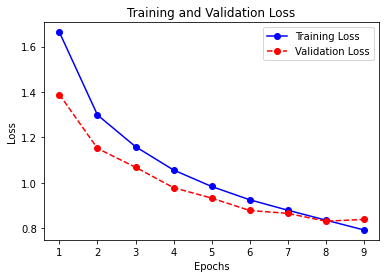

In [13]:
#顯示圖表來分析模型的訓練過程
#滙入matplotlib.pyplot類別
import matplotlib.pyplot as plt 

#顯示訓練和驗證損失
#取得訓練過程中訓練資料的每一個週期損失函數值
loss = history.history["loss"]         
#設定週期範圍
epochs = range(1, len(loss)+1)         
#取得訓練過程中驗證資料的每一個週期損失函數值
val_loss = history.history["val_loss"] 
#驗證資料的每一個週期損失函數值
#X座標:epochs， y座標:loss, 線的型態為bo-，圖標為Training Loss
plt.plot(epochs, loss, "bo-", label="Training Loss") 
#X座標:epochs， y座標:loss, 線的型態為ro-，圖標為Validation Loss
plt.plot(epochs, val_loss, "ro--", label="Validation Loss")
#設定圖片的標題
plt.title("Training and Validation Loss")
#設定圖片的X軸標題 
plt.xlabel("Epochs")    
#設定圖片的Y軸標題
plt.ylabel("Loss")      
#要顯示座標軸上的刻度、數字
plt.legend()            
#將圖片顯示出來
plt.show()         

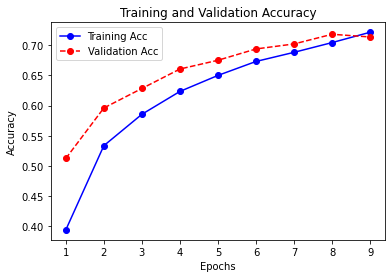

In [14]:
#顯示訓練和驗證準確率
#取得訓練過程中訓練資料的每一個週期準確率
acc = history.history["accuracy"]    
#設定週期範圍
epochs = range(1, len(acc)+1)   
#取得訓練過程中驗證資料的每一個週期準確率
val_acc = history.history["val_accuracy"]   
#X座標:epochs， y座標:loss, 線的型態為bo-，圖標為Training Acc
plt.plot(epochs, acc, "bo-", label="Training Acc")
#X座標:epochs， y座標:loss, 線的型態為ro-，圖標為Validation Acc
plt.plot(epochs, val_acc, "ro--", label="Validation Acc")
#設定圖片的標題
plt.title("Training and Validation Accuracy")
#設定圖片的X軸標題
plt.xlabel("Epochs")    
#設定圖片的Y軸標題
plt.ylabel("Accuracy")  
#要顯示座標軸上的刻度、數字
plt.legend()     
#將圖片顯示出來       
plt.show()

In [15]:
#3.6 載入模型並使用混淆矩陣分析預測結果
#載入pandas函數庫(套件)
import pandas as pd
#載入load_model函數
from tensorflow.keras.models import load_model 

#載入資料集
(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()
#因為是固定範圍, 所以執行正規化, 從 0-255 至 0-1
X_test = X_test.astype("float32") / 255
#備份 Y_test 資料集
Y_test_bk = Y_test.copy()       
#將標籤資料改用one-hot編碼
Y_test = to_categorical(Y_test)  

#建立Keras的Sequential模型
#建立一個序列模型
model = Sequential()   
#載入之前建立的模型
model = load_model("cifar10.h5") 
#編譯模型
 #損失函數為categorical_crossentropy
 #最佳化方式採用Adam
 #評估指標使用accuracy
model.compile(loss="categorical_crossentropy", optimizer="adam",
              metrics=["accuracy"])
# 評估模型
print("Testing ...")
#計算測試資料集的準確度 
loss, accuracy = model.evaluate(X_test, Y_test) 
print("測試資料集的準確度 = %.2f" % (accuracy))
# 計算分類的預測值
print("\nPredicting ...")
#使用模型來預測測試資料的類別 
#Y_pred = model.predict_classes(X_test)  #tf2.2

Y_pred = model.predict(X_test) #new tf2.4 
Y_pred = np.argmax(Y_pred, axis=1)

#顯示混淆矩陣
#crosstab的第1個參數為列的資料，第2個參數為欄的資料, rownames為列的標籤, colnames為欄的標籤
tb = pd.crosstab(Y_test_bk.astype(int).flatten(), 
                 Y_pred.astype(int),
                 rownames=["label"], colnames=["predict"])
print(tb)  #顯示混淆矩陣
tb.to_html("example3_1.html") #儲存成HTML檔案

Testing ...
313/313 [==============================] - 3s 10ms/step - loss: 0.8494 - accuracy: 0.7046
測試資料集的準確度 = 0.70

Predicting ...
predict    0    1    2    3    4    5    6    7    8    9
label                                                    
0        826   10   21   14    8    6    4   13   71   27
1         36  802   11   10    2    9    4    6   32   88
2         99    6  603   56   72   78   31   38   10    7
3         50   10   74  483   60  242   19   39   14    9
4         46    4  104   56  613   58   22   84   13    0
5         29    3   58  123   31  683   10   49   11    3
6         12    4   64  105   55   59  674   12    8    7
7         19    1   41   23   36   84    1  782    6    7
8         86   32    7   10    8    8    4    8  825   12
9         60   75   14   13    8   14    4   19   38  755


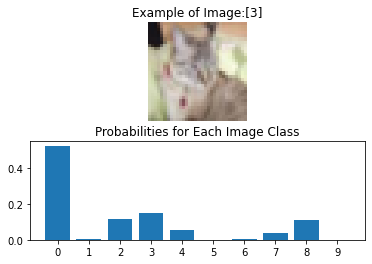

In [16]:
#3.7 繪出某1張圖片之0-9分類的預測機率
#選一個測試的圖片 
i = 8  
#取出編號為8的圖片資料，為1個3D張量
img = X_test[i]   
#將圖片轉換成4D張量
X_test_img = img.reshape(1, 32, 32, 3).astype("float32") 
#正規化
X_test_img = X_test_img / 255  
#建立一個序列模型
model = Sequential() 
#載入之前建立的模型
model = load_model("cifar10.h5") 
#編譯模型
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"]) 

#繪出圖表的預測結果
plt.figure() 
#子圖在2列1欄中的第1列(在上面的圖)
plt.subplot(2,1,1)  
#設定圖標
plt.title("Example of Image:" + str(Y_test_bk[i])) 
#顯示圖片 
plt.imshow(img, cmap="binary")                  
#不顯示座標軸
plt.axis("off")                                 
#預測結果的機率

#probs = model.predict_proba(X_test_img, batch_size=1) #old tf2.X
probs = model.predict(X_test_img, batch_size=1) #new tf2.4

#子圖在2列1欄中的第2列(在下面的圖)
plt.subplot(2,1,2)
#設定圖標
plt.title("Probabilities for Each Image Class")   
#繪製長條圖
plt.bar(np.arange(10), probs.reshape(10), align="center")
#顯示x軸上的標記數字
plt.xticks(np.arange(10),np.arange(10).astype(str))       
#將圖繪製出來
plt.show()
